# Palm Club - Outlier, Leverage & Influence Analysis

## Conceptual Framing
All four diagnostics (hat values, Cook's D, DFBETAS, DFFITS) are defined relative to a fitted regression model. They measure how much each observation shapes the model rather than existing independently. 

| Model | Type | Outcome | Primary Question |
|---|---|---|---|
|M1 |Logistic| Churned|Which employees are most influential on the churn prediction?|
|M2|OLS | TenureMonths | Who has anomalous tenure given their profile?|
|M3 |OLS | MonthsToPromotion| Who is an outlier in how long they waited for promotion?|

Theoretical Reference

Leverage — Hat Diagonal (hᵢᵢ)
- Hat values come from the hat matrix H = X(XᵀX)⁻¹Xᵀ, where each diagonal entry hᵢᵢ measures how far observation i sits from the centre of the predictor space. 
- High leverage means the observation has an unusual combination of predictors — it could be pulling the regression line, whether or not it actually does.
- Rule of thumb: hᵢᵢ > 2(p+1)/n is high leverage, where p = number of predictors and n = sample size.

Influence — Cook's Distance (Dᵢ)
- Cook's D combines leverage and residual size into one number — it measures how much all fitted values would shift if observation i were removed. 
- A large Cook's D means the observation is both unusual in predictor space AND poorly fitted.
- Rule of thumb: Dᵢ > 4/n warrants investigation. Dᵢ > 1 is severe.

DFBETAS
- DFBETAS measures the change in each individual regression coefficient when observation i is removed, scaled by the coefficient's standard error. 
- You get one DFBETAS value per predictor per observation — useful for identifying which specific employees are driving which specific relationships.
- Rule of thumb: |DFBETASᵢⱼ| > 2/√n is influential on coefficient j.

DFFITS
- DFFITS measures the change in the fitted value for observation i when it is removed from the model, scaled by the standard error. 
- Unlike Cook's D (which looks at all fitted values), DFFITS is self-focused — how much does removing i change i's own prediction?
- Rule of thumb: |DFFITSᵢ| > 2√(p+1)/n is influential.

# Section 0 - Setup & Load

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import OLSInfluence, MLEInfluence
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Load the master table built in the EDA notebook
employee = pd.read_csv("employee_master.csv")

# Restore date dtype
employee["HiredOn"] = pd.to_datetime(employee["HiredOn"])

print(f"Rows: {len(employee)}")
print(employee[["AvgPerfScore", "TenureMonths", "Churned", "IsHighPerformer"]].describe())

Rows: 1067
       AvgPerfScore  TenureMonths      Churned  IsHighPerformer
count   1067.000000   1067.000000  1067.000000      1067.000000
mean      79.205820      6.380182     0.882849         0.250234
std        8.494022      6.641459     0.321751         0.433351
min       58.070000      0.000000     0.000000         0.000000
25%       73.590000      1.642576     1.000000         0.000000
50%       79.320000      4.204993     1.000000         0.000000
75%       85.445000      8.968463     1.000000         0.500000
max       98.200000     45.006570     1.000000         1.000000


In [5]:

# ── Recompute MonthsToPromotion from the changes table ──────────────────────
changes = pd.read_csv("data/BOLT_EmployeeChanges.csv")
changes["DateChanged"] = pd.to_datetime(changes["DateChanged"])

PROMOTION_LABELS = ["Bartender", "Server", "Manager", "Shift Lead", "Server Assistant"]

first_promo = (
    changes[changes["New Role"].isin(PROMOTION_LABELS)]
    .sort_values("DateChanged")
    .groupby("EmployeeID")["DateChanged"]
    .first()
    .rename("FirstPromoDate")
    .reset_index()
)

In [7]:
employee = employee.merge(first_promo, on="EmployeeID", how="left")
employee["FirstPromoDate"]    = pd.to_datetime(employee["FirstPromoDate"])
employee["EverPromoted"]      = employee["FirstPromoDate"].notna().astype(int)
employee["MonthsToPromotion"] = (
    (employee["FirstPromoDate"] - employee["HiredOn"]).dt.days / 30.44
)

# Sanity check
print(f"Ever promoted:    {employee['EverPromoted'].sum()}")
print(f"Never promoted:   {(employee['EverPromoted']==0).sum()}")
print(f"MonthsToPromotion range: "
      f"{employee['MonthsToPromotion'].min():.1f} – "
      f"{employee['MonthsToPromotion'].max():.1f}")

Ever promoted:    178
Never promoted:   889
MonthsToPromotion range: 0.0 – 15.8


# Section 1 - Feature Engineering for Regression

In [8]:
# --- Encode categoricals ---
le = LabelEncoder()
employee["Role_enc"] = le.fit_transform(employee["Role"].astype(str))
employee["Wage_enc"] = le.fit_transform(employee["Wage"].astype(str))
employee["Branch_enc"] = le.fit_transform(employee["Branch#"].astype(str))
employee["Position_enc"] = le.fit_transform(employee["Position"].astype(str))

# --- Drop rows with missing values in any predictor ---
# (employees with no performance record can't be included)
MODEL_COLS = [
    "AvgPerfScore", "TenureMonths", "AvgWorkingHours/Week",
    "Role_enc", "Wage_enc", "Branch_enc", "Position_enc",
    "AgeAtHire", "YearsOfRelevantExperience",
    "Churned", "MonthsToPromotion", "IsHighPerformer", "EmployeeID"
]

df = employee[MODEL_COLS].dropna().copy()
df = df.reset_index(drop=True)  # critical — influence indices must align with df rows

print(f"Rows after dropping NaN: {len(df)} (dropped {len(employee) - len(df)})")

Rows after dropping NaN: 178 (dropped 889)


# Section 2: Model 1 - Logistic Regression

## (A) - Fitting the Model

In [12]:

PREDICTORS_M1 = [
    "AvgPerfScore", "AvgWorkingHours/Week",
    "Wage_enc", "Role_enc", "AgeAtHire", "YearsOfRelevantExperience", "TenureMonths"
]

# ── Step 1: Check for perfect separation on TenureMonths ──
print("Churn rate by tenure quartile:")
df["TenureQ"] = pd.qcut(df["TenureMonths"], q=4)
print(df.groupby("TenureQ")["Churned"].mean().round(3))
df.drop(columns="TenureQ", inplace=True)

# ── Step 2: Check correlation between encoded predictors ──
print("\nCorrelation matrix of predictors:")
print(df[PREDICTORS_M1].corr().round(2))

# ── Step 3: Check variance — zero variance columns will break the model ──
print("\nVariance of each predictor:")
print(df[PREDICTORS_M1].var().round(4))

# ── Step 4: Check class balance ──
print(f"\nChurn rate in df: {df['Churned'].mean():.1%}")
print(df["Churned"].value_counts())

Churn rate by tenure quartile:
TenureQ
(6.864999999999999, 12.623]    0.933
(12.623, 16.212]               0.818
(16.212, 21.386]               0.750
(21.386, 45.007]               0.711
Name: Churned, dtype: float64

Correlation matrix of predictors:
                           AvgPerfScore  AvgWorkingHours/Week  Wage_enc  \
AvgPerfScore                       1.00                 -0.06     -0.02   
AvgWorkingHours/Week              -0.06                  1.00      0.03   
Wage_enc                          -0.02                  0.03      1.00   
Role_enc                          -0.03                  0.06      0.05   
AgeAtHire                         -0.11                  0.02      0.01   
YearsOfRelevantExperience          0.06                 -0.11      0.12   
TenureMonths                       0.12                  0.16      0.10   

                           Role_enc  AgeAtHire  YearsOfRelevantExperience  \
AvgPerfScore                  -0.03      -0.11                       0

/var/folders/f9/xx_tnkhj4lx3ylbk98sjxw7h0000gn/T/ipykernel_85251/1255673321.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("TenureQ")["Churned"].mean().round(3))


In [13]:
# Use solver='lbfgs' which handles near-singular cases better than Newton-Raphson
# Also drop TenureMonths from M1 — it's used as the OUTCOME in M2, 
# and near-perfect separation on tenure is likely causing the singularity

X1 = sm.add_constant(df[PREDICTORS_M1])
y1 = df["Churned"]

# Regularised logistic regression — adds a small penalty to stabilise the Hessian
logit_model = sm.Logit(y1, X1).fit_regularized(
    method="l1",
    alpha=0.1,       # regularisation strength — increase if still singular
    disp=False
)
print(logit_model.summary())

                           Logit Regression Results                           
Dep. Variable:                Churned   No. Observations:                  178
Model:                          Logit   Df Residuals:                      170
Method:                           MLE   Df Model:                            7
Date:                Wed, 18 Mar 2026   Pseudo R-squ.:                  0.9767
Time:                        23:34:46   Log-Likelihood:                -2.0518
converged:                       True   LL-Null:                       -88.234
Covariance Type:            nonrobust   LLR p-value:                 7.968e-34
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        35.4109     12.538      2.824      0.005      10.837      59.985
AvgPerfScore                  0.4161      0.274      1.517      0.129      -0.122     

/Users/takshgirdhar/Desktop/BOLT Case Comp/BOLT_Case_Competition/.venv/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Users/takshgirdhar/Desktop/BOLT Case Comp/BOLT_Case_Competition/.venv/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


## (B) - Leverage (Hat Values)

Leverage threshold (2p/n): 0.0899
High leverage observations: 22


/Users/takshgirdhar/Desktop/BOLT Case Comp/BOLT_Case_Competition/.venv/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:5312: RuntimeWarning: invalid value encountered in divide
  return (endog - M*p)/np.sqrt(M*p*(1-p))


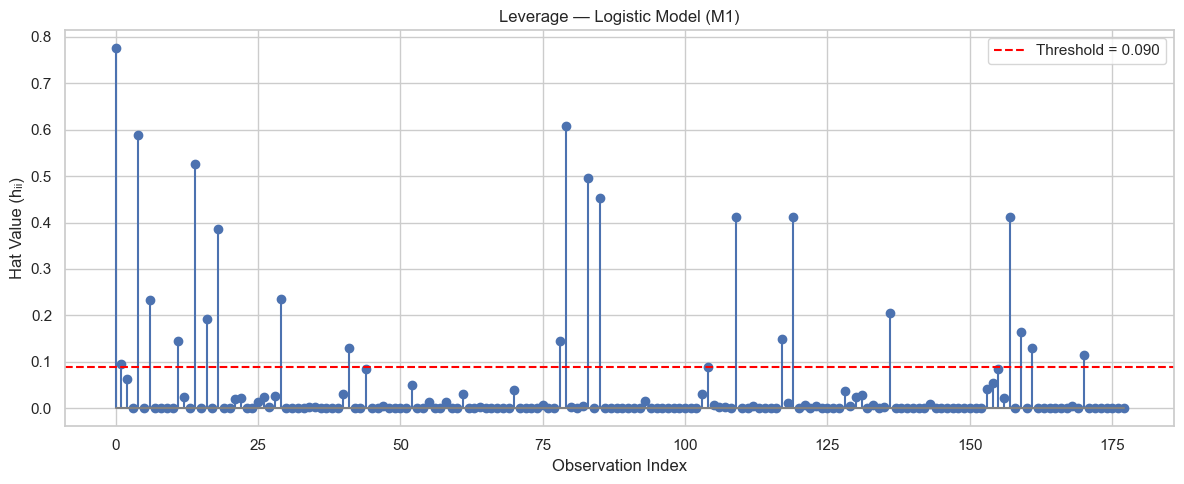

In [14]:
influence_m1 = MLEInfluence(logit_model)

hat_vals = influence_m1.hat_matrix_diag
p = X1.shape[1]      # number of params including constant
n = len(df)
leverage_threshold = 2 * p / n

df["hat_M1"] = hat_vals

print(f"Leverage threshold (2p/n): {leverage_threshold:.4f}")
print(f"High leverage observations: {(df['hat_M1'] > leverage_threshold).sum()}")

# Plot
plt.figure(figsize=(12, 5))
plt.stem(df.index, df["hat_M1"], markerfmt="C0o", linefmt="C0-", basefmt="grey")
plt.axhline(leverage_threshold, color="red", linestyle="--", label=f"Threshold = {leverage_threshold:.3f}")
plt.xlabel("Observation Index")
plt.ylabel("Hat Value (hᵢᵢ)")
plt.title("Leverage — Logistic Model (M1)")
plt.legend()
plt.tight_layout()

## (C) - Cook's Distance

Cook's D > 4/n (0.0225): 178 observations
Cook's D > 1.0: 3 observations


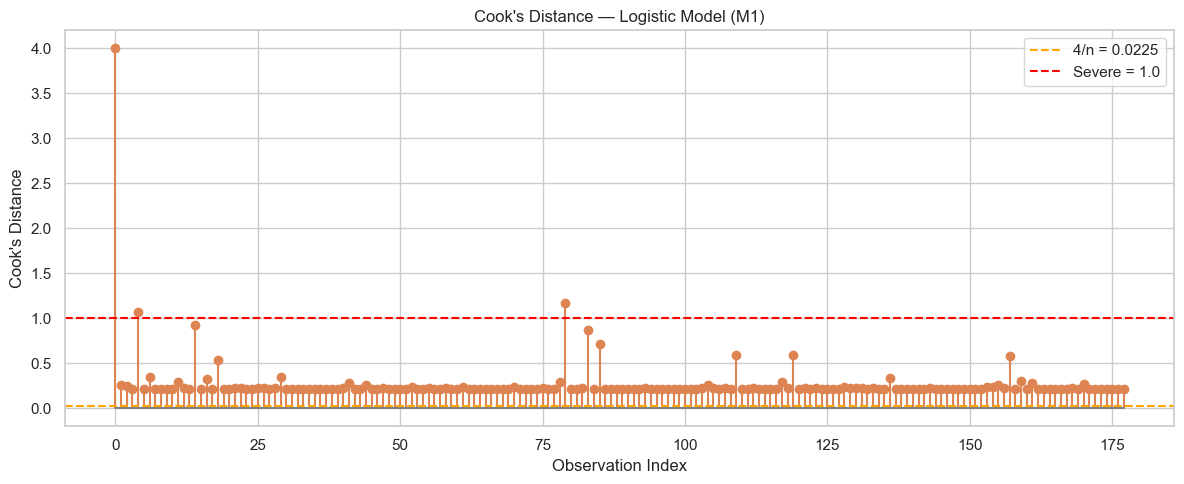

In [15]:
cooks_d = influence_m1.cooks_distance[0]
cooks_threshold_soft = 4 / n      # investigate
cooks_threshold_hard = 1.0        # severe

df["cooks_M1"] = cooks_d

print(f"Cook's D > 4/n ({cooks_threshold_soft:.4f}): {(df['cooks_M1'] > cooks_threshold_soft).sum()} observations")
print(f"Cook's D > 1.0: {(df['cooks_M1'] > cooks_threshold_hard).sum()} observations")

# Plot
plt.figure(figsize=(12, 5))
plt.stem(df.index, df["cooks_M1"], markerfmt="C1o", linefmt="C1-", basefmt="grey")
plt.axhline(cooks_threshold_soft, color="orange", linestyle="--", label=f"4/n = {cooks_threshold_soft:.4f}")
plt.axhline(cooks_threshold_hard, color="red",    linestyle="--", label="Severe = 1.0")
plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance — Logistic Model (M1)")
plt.legend()
plt.tight_layout()

## (D) - DFBETAS

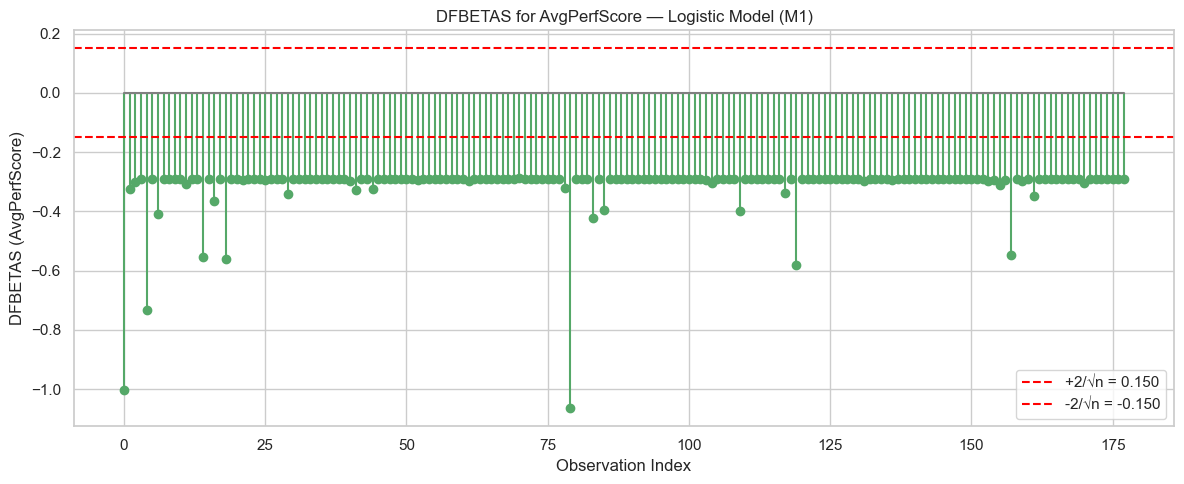


Employees influential on AvgPerfScore  coefficient: 178


In [16]:
dfbetas = influence_m1.dfbetas          # shape: (n, p)
dfbetas_threshold = 2 / np.sqrt(n)

# Map column positions — constant is index 0, predictors follow in order
pred_idx = {name: i+1 for i, name in enumerate(PREDICTORS_M1)}

for pred in ["AvgPerfScore"]:
    col_idx = pred_idx[pred]
    dfb = dfbetas[:, col_idx]
    
    plt.figure(figsize=(12, 5))
    plt.stem(range(n), dfb, markerfmt="C2o", linefmt="C2-", basefmt="grey")
    plt.axhline( dfbetas_threshold, color="red", linestyle="--", label=f"+2/√n = {dfbetas_threshold:.3f}")
    plt.axhline(-dfbetas_threshold, color="red", linestyle="--", label=f"-2/√n = -{dfbetas_threshold:.3f}")
    plt.xlabel("Observation Index")
    plt.ylabel(f"DFBETAS ({pred})")
    plt.title(f"DFBETAS for {pred} — Logistic Model (M1)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Flag employees influential on either key coefficient
df["dfbeta_perf_M1"]   = dfbetas[:, pred_idx["AvgPerfScore"]]


influential_dfbetas = df[
    (df["dfbeta_perf_M1"].abs()   > dfbetas_threshold)
]
print(f"\nEmployees influential on AvgPerfScore  coefficient: {len(influential_dfbetas)}")

## (E) - Combined Influence Plot: Leverage vs. Cook's D

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

# Colour by IsHighPerformer so the segment of interest stands out
colors = df["IsHighPerformer"].map({1: "#DD8452", 0: "#4C72B0"})

scatter = ax.scatter(
    df["hat_M1"], df["cooks_M1"],
    c=colors, alpha=0.6, edgecolors="white", linewidth=0.5, s=40
)

ax.axvline(leverage_threshold,    color="red",    linestyle="--", alpha=0.7, label=f"Leverage threshold")
ax.axhline(cooks_threshold_soft,  color="orange", linestyle="--", alpha=0.7, label=f"Cook's D (4/n)")
ax.axhline(cooks_threshold_hard,  color="red",    linestyle="--", alpha=0.7, label=f"Cook's D (1.0)")

# Label the most extreme points
top_influential = df.nlargest(10, "cooks_M1")
for _, row in top_influential.iterrows():
    ax.annotate(
        str(int(row["EmployeeID"])),
        (row["hat_M1"], row["cooks_M1"]),
        fontsize=7, xytext=(4, 4), textcoords="offset points"
    )

# Legend patches for colour
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#DD8452", label="High Performer"),
    Patch(facecolor="#4C72B0", label="Other"),
]
ax.legend(handles=legend_elements + ax.get_legend_handles_labels()[0][3:], fontsize=9)
ax.set_xlabel("Leverage (hᵢᵢ)")
ax.set_ylabel("Cook's Distance")
ax.set_title("Leverage vs. Cook's Distance — Logistic Model M1\n(top-right quadrant = high leverage AND high influence)")
plt.tight_layout()

## (F) - Profile Flagged Employees

In [17]:
# Flag any employee that exceeds at least one threshold
df["flagged_M1"] = (
    (df["hat_M1"]            > leverage_threshold)   |
    (df["cooks_M1"]          > cooks_threshold_soft) |
    (df["dfbeta_perf_M1"].abs()   > dfbetas_threshold) 
)

flagged = df[df["flagged_M1"]][[
    "EmployeeID", "AvgPerfScore", "TenureMonths", "IsHighPerformer",
    "Churned", "hat_M1", "cooks_M1",
    "dfbeta_perf_M1"
]].sort_values("cooks_M1", ascending=False)

print(f"\nTotal flagged employees (M1): {len(flagged)}")
display(flagged.head(20))


Total flagged employees (M1): 178


,EmployeeID,AvgPerfScore,TenureMonths,IsHighPerformer,Churned,hat_M1,cooks_M1,dfbeta_perf_M1
0,5764,90.31,45.006570,1,0,0.775121,3.999642,-1.002156
79,5853,90.92,23.061761,1,0,0.608972,1.167922,-1.064441
4,5572,90.71,13.961892,1,0,0.589012,1.074009,-0.732257
14,5401,75.45,15.932983,0,1,0.525335,0.928446,-0.553552
83,5680,68.69,10.216820,0,0,0.496987,0.874425,-0.422873
85,5209,89.43,29.336399,1,1,0.452310,0.708870,-0.393850
109,5534,81.91,27.890933,0,1,0.412825,0.594178,-0.399369
119,5289,72.62,13.929041,0,1,0.411673,0.586620,-0.582599
157,5822,84.75,33.541393,0,1,0.413042,0.580957,-0.546369
18,5979,67.47,13.337714,0,1,0.387087,0.537579,-0.559565


In [20]:
branch = pd.read_csv("data/BOLT_Branch.csv")

# ── Full profile for all flagged employees ──────────────────────────────────

# Pull from the original employee table (has all columns including branch join key)
profile_cols = [
    # Identity
    "EmployeeID",

    # Role & location
    "Role", "Position", "Branch#",

    # Employment timeline
    "HiredOn", "TenureMonths", "EverPromoted", "MonthsToPromotion",

    # Performance & compensation
    "AvgPerfScore", "IsHighPerformer", "Wage",

    # Working pattern
    "AvgWorkingHours/Week",

    # Outcome
    "Churned", "Current status",

    # Applicant background
    "HighestEducationLevel", "YearsOfRelevantExperience",
    "PastRelevantExperience", "AgeAtHire", "YearOfBirth",
]

# Get flagged EmployeeIDs from df (the modelling dataframe)
flagged_ids = df[df["flagged_M1"]]["EmployeeID"].values

# Pull full profiles from employee (has branch details etc.)
flagged_profiles = employee[employee["EmployeeID"].isin(flagged_ids)].copy()

# ── Merge branch details ─────────────────────────────────────────────────────
branch_renamed = branch.rename(columns={"BranchNo": "Branch#"})
branch_info = branch_renamed[["Branch#", "BranchName", "Stars"]].copy()

# Average stars per branch (branch table has one row per review)
branch_avg = (
    branch_info.groupby(["Branch#", "BranchName"])["Stars"]
    .mean()
    .round(2)
    .reset_index()
    .rename(columns={"Stars": "BranchAvgStars"})
)

flagged_profiles = flagged_profiles.merge(branch_avg, on="Branch#", how="left")

# ── Add influence metrics from df ────────────────────────────────────────────
influence_cols = df[df["flagged_M1"]][[
    "EmployeeID", "hat_M1", "cooks_M1", "dfbeta_perf_M1"
]].copy()

flagged_profiles = flagged_profiles.merge(influence_cols, on="EmployeeID", how="left")

# ── Add human-readable flag reason ───────────────────────────────────────────
def flag_reason(row):
    reasons = []
    if row["hat_M1"]           > leverage_threshold:  reasons.append("High Leverage")
    if row["cooks_M1"]         > cooks_threshold_soft: reasons.append("High Cook's D")
    if abs(row["dfbeta_perf_M1"]) > dfbetas_threshold: reasons.append("DFBETA PerfScore")
    return " | ".join(reasons)

flagged_profiles["FlagReason"] = flagged_profiles.apply(flag_reason, axis=1)

# ── Readable labels ───────────────────────────────────────────────────────────
flagged_profiles["PerformanceTier"] = flagged_profiles["IsHighPerformer"].map(
    {1: "High Performer", 0: "Other"}
)
flagged_profiles["PromotionStatus"] = flagged_profiles["EverPromoted"].map(
    {1: "Promoted", 0: "Never Promoted"}
)
flagged_profiles["MonthsToPromotion"] = flagged_profiles["MonthsToPromotion"].round(1)
flagged_profiles["TenureMonths"]      = flagged_profiles["TenureMonths"].round(1)
flagged_profiles["AvgPerfScore"]      = flagged_profiles["AvgPerfScore"].round(2)
flagged_profiles["hat_M1"]            = flagged_profiles["hat_M1"].round(4)
flagged_profiles["cooks_M1"]          = flagged_profiles["cooks_M1"].round(4)
flagged_profiles["dfbeta_perf_M1"]    = flagged_profiles["dfbeta_perf_M1"].round(4)

# ── Final column order ────────────────────────────────────────────────────────
final_cols = [
    # Identity & flag
    "EmployeeID", "FlagReason", "PerformanceTier",

    # Role & location
    "Role", "Position", "Branch#", "BranchName", "BranchAvgStars",

    # Compensation & hours
    "Wage", "AvgWorkingHours/Week",

    # Timeline
    "HiredOn", "TenureMonths", "PromotionStatus", "MonthsToPromotion",

    # Outcome
    "Current status", "Churned",

    # Performance
    "AvgPerfScore",

    # Application background
    "AgeAtHire", "HighestEducationLevel",
    "YearsOfRelevantExperience", "PastRelevantExperience",

    # Influence metrics
    "hat_M1", "cooks_M1", "dfbeta_perf_M1",
]

# Keep only columns that exist (guards against any missing after merges)
final_cols = [c for c in final_cols if c in flagged_profiles.columns]
flagged_profiles = flagged_profiles[final_cols].sort_values("cooks_M1", ascending=False)

print(f"Flagged employee profiles: {len(flagged_profiles)}")
display(flagged_profiles)

flagged_profiles.to_csv("Outliers_Analysis/flagged_employee_profiles_M1.csv", index=False)
print("Saved: flagged_employee_profiles_M1.csv")

Flagged employee profiles: 178


,EmployeeID,FlagReason,PerformanceTier,Role,Position,Branch#,BranchName,BranchAvgStars,Wage,AvgWorkingHours/Week,...,Current status,Churned,AvgPerfScore,AgeAtHire,HighestEducationLevel,YearsOfRelevantExperience,PastRelevantExperience,hat_M1,cooks_M1,dfbeta_perf_M1
0,5764,High Leverage | High Cook's D | DFBETA PerfScore,High Performer,Manager,full-time,1,UBC,3.98,Minimum,48.8,...,Working,0,90.31,18,Bachelor,2,True,0.7751,3.9996,-1.0022
79,5853,High Leverage | High Cook's D | DFBETA PerfScore,High Performer,Manager,full-time,4,Main Street,3.79,Minimum,49.1,...,Working,0,90.92,27,Bachelor,2,True,0.6090,1.1679,-1.0644
4,5572,High Leverage | High Cook's D | DFBETA PerfScore,High Performer,Manager,full-time,1,UBC,3.98,Competitive,49.0,...,Working,0,90.71,26,Bachelor,4,True,0.5890,1.0740,-0.7323
14,5401,High Leverage | High Cook's D | DFBETA PerfScore,Other,Bartender,full-time,1,UBC,3.98,Minimum,42.8,...,Left,1,75.45,23,Bachelor,0,False,0.5253,0.9284,-0.5536
83,5680,High Leverage | High Cook's D | DFBETA PerfScore,Other,Shift Lead,full-time,4,Main Street,3.79,Minimum,45.0,...,Working,0,68.69,21,Associate Degree,0,False,0.4970,0.8744,-0.4229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,5985,High Cook's D | DFBETA PerfScore,High Performer,Bartender,full-time,3,Downtown,3.91,Minimum,40.5,...,Left,1,89.69,27,Associate Degree,2,True,0.0002,0.2183,-0.2894
68,5882,High Cook's D | DFBETA PerfScore,High Performer,Bartender,part-time,3,Downtown,3.91,Competitive,24.3,...,Left,1,88.99,18,Associate Degree,4,True,0.0000,0.2183,-0.2894
67,5496,High Cook's D | DFBETA PerfScore,High Performer,Bartender,full-time,3,Downtown,3.91,Competitive,39.3,...,Fired,1,95.31,21,Bachelor,3,True,0.0000,0.2183,-0.2894
66,5225,High Cook's D | DFBETA PerfScore,High Performer,Bartender,full-time,3,Downtown,3.91,Competitive,39.8,...,Left,1,95.52,21,Bachelor,3,True,0.0000,0.2183,-0.2894


Saved: flagged_employee_profiles_M1.csv


# Section 3: Model 2 - OLS on TenureMonths

## (A) Fit the Model

In [21]:
PREDICTORS_M2 = [
    "AvgPerfScore", "AvgWorkingHours/Week",
    "Wage_enc", "Role_enc", "AgeAtHire",
    "YearsOfRelevantExperience", "IsHighPerformer"
]

# Only use exited employees — tenure is only meaningful at exit
df_exited = df[df["Churned"] == 1].copy().reset_index(drop=True)

X2 = sm.add_constant(df_exited[PREDICTORS_M2])
y2 = df_exited["TenureMonths"]

ols_m2 = sm.OLS(y2, X2).fit()
print(ols_m2.summary())

                            OLS Regression Results                            
Dep. Variable:           TenureMonths   R-squared:                       0.220
Model:                            OLS   Adj. R-squared:                  0.180
Method:                 Least Squares   F-statistic:                     5.440
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           1.61e-05
Time:                        23:36:32   Log-Likelihood:                -459.69
No. Observations:                 143   AIC:                             935.4
Df Residuals:                     135   BIC:                             959.1
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

## (B) Full Diagnostic Suite

In [22]:
influence_m2 = OLSInfluence(ols_m2)

n2 = len(df_exited)
p2 = X2.shape[1]

# Thresholds
lev_thresh_m2    = 2 * p2 / n2
cooks_thresh_m2  = 4 / n2
dffits_thresh_m2 = 2 * np.sqrt(p2 / n2)
dfbeta_thresh_m2 = 2 / np.sqrt(n2)

df_exited["hat_M2"]    = influence_m2.hat_matrix_diag
df_exited["cooks_M2"]  = influence_m2.cooks_distance[0]
df_exited["dffits_M2"] = influence_m2.dffits[0]
df_exited["resid_M2"]  = ols_m2.resid

# DFBETAS for AvgPerfScore
dfbetas_m2 = influence_m2.dfbetas
pred_idx_m2 = {name: i+1 for i, name in enumerate(PREDICTORS_M2)}
df_exited["dfbeta_perf_M2"] = dfbetas_m2[:, pred_idx_m2["AvgPerfScore"]]

print("=== Model 2 Influence Summary ===")
print(f"High leverage (>{lev_thresh_m2:.4f}):    {(df_exited['hat_M2'] > lev_thresh_m2).sum()}")
print(f"High Cook's D (>{cooks_thresh_m2:.4f}):  {(df_exited['cooks_M2'] > cooks_thresh_m2).sum()}")
print(f"High |DFFITS| (>{dffits_thresh_m2:.4f}): {(df_exited['dffits_M2'].abs() > dffits_thresh_m2).sum()}")

=== Model 2 Influence Summary ===
High leverage (>0.1119):    6
High Cook's D (>0.0280):  10
High |DFFITS| (>0.4730): 10


## (C) - Residual Plot: Actual vs. Predicted

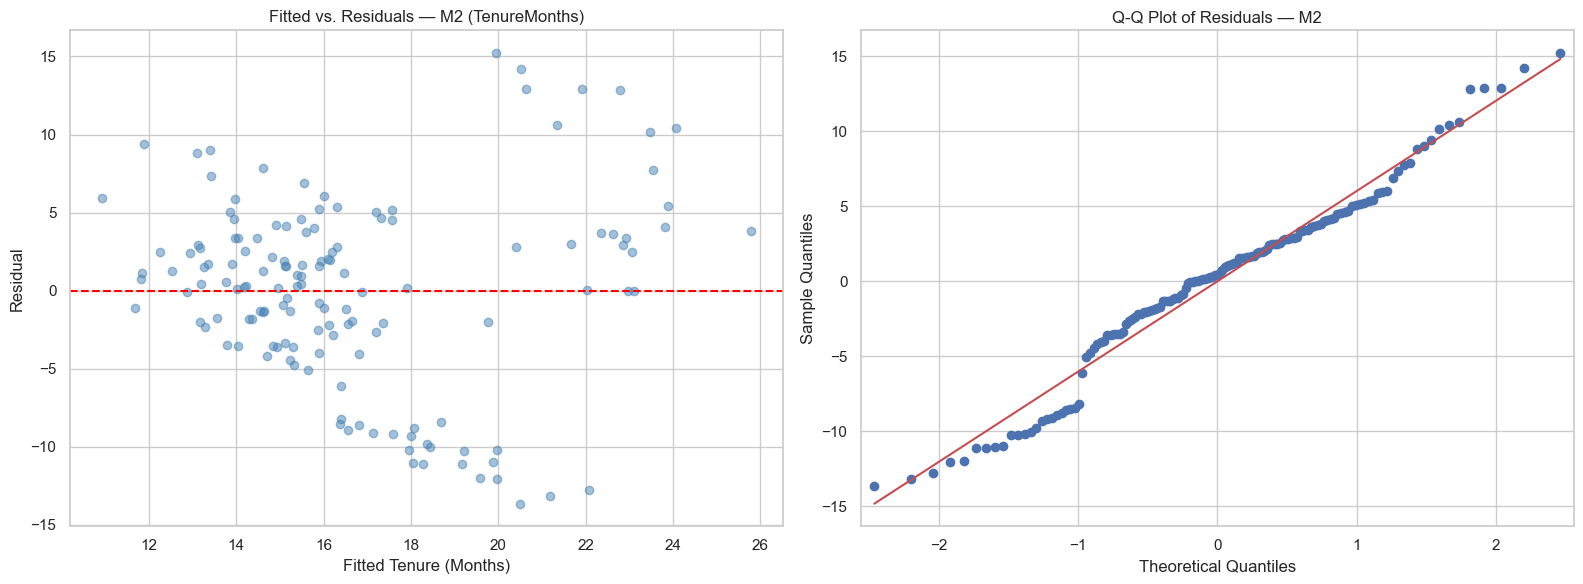

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Fitted vs Residuals
axes[0].scatter(ols_m2.fittedvalues, ols_m2.resid, alpha=0.5, color="steelblue")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Fitted Tenure (Months)")
axes[0].set_ylabel("Residual")
axes[0].set_title("Fitted vs. Residuals — M2 (TenureMonths)")

# Q-Q plot
sm.qqplot(ols_m2.resid, line="s", ax=axes[1])
axes[1].set_title("Q-Q Plot of Residuals — M2")

plt.tight_layout()

## (D) Combinbed Plot + Flag

Flagged employees (M2): 19


,EmployeeID,AvgPerfScore,TenureMonths,IsHighPerformer,hat_M2,cooks_M2,resid_M2
81,6045,82.40,34.526938,0,0.138351,0.066186,10.450196
100,5046,89.60,7.917214,1,0.106499,0.062901,-12.040826
21,5946,73.51,35.183968,0,0.070185,0.061219,15.227338
122,5822,84.75,33.541393,0,0.091313,0.059939,12.909354
63,5756,81.06,34.724047,0,0.064474,0.048363,14.207645
0,5203,94.64,35.643890,1,0.056030,0.033798,12.855666
42,5930,93.49,34.822602,1,0.054496,0.033005,12.902480
98,5482,95.52,9.296978,1,0.055092,0.032770,-12.778732
99,5127,90.64,8.048620,1,0.048678,0.030221,-13.143651
62,5914,80.24,7.161629,0,0.064945,0.029838,-11.113552


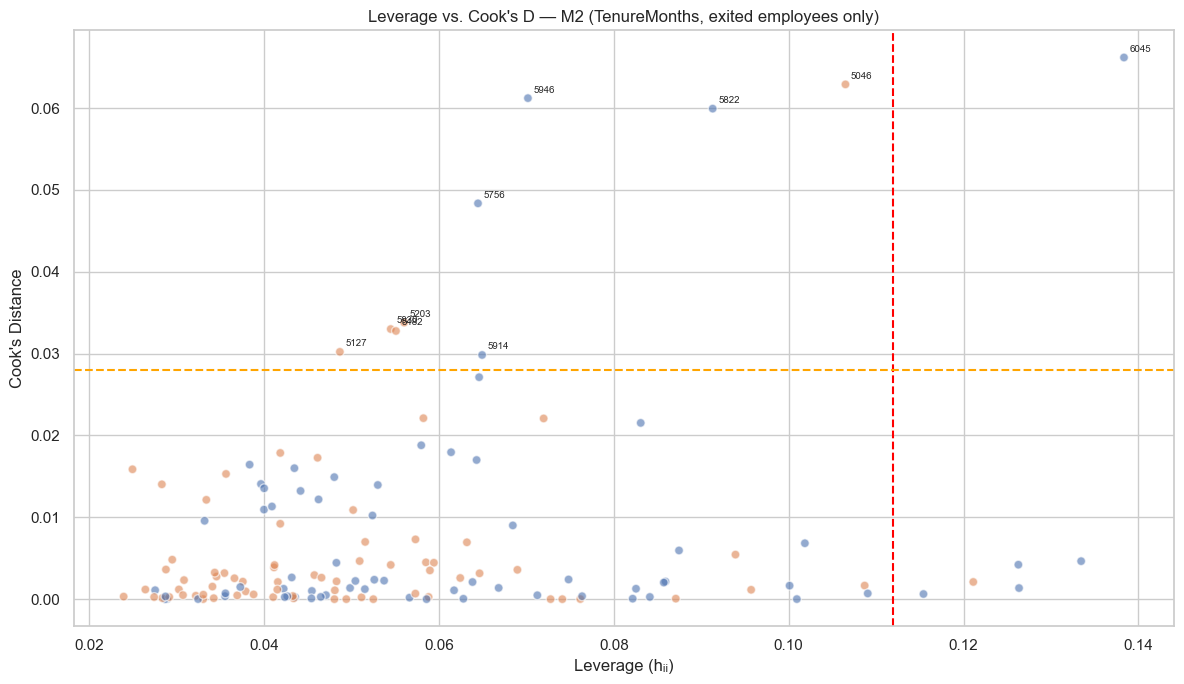

In [24]:
# Leverage vs Cook's D — colour by IsHighPerformer
fig, ax = plt.subplots(figsize=(12, 7))
colors2 = df_exited["IsHighPerformer"].map({1: "#DD8452", 0: "#4C72B0"})
ax.scatter(df_exited["hat_M2"], df_exited["cooks_M2"],
           c=colors2, alpha=0.6, edgecolors="white", s=40)
ax.axvline(lev_thresh_m2,   color="red",    linestyle="--")
ax.axhline(cooks_thresh_m2, color="orange", linestyle="--")
ax.set_xlabel("Leverage (hᵢᵢ)")
ax.set_ylabel("Cook's Distance")
ax.set_title("Leverage vs. Cook's D — M2 (TenureMonths, exited employees only)")

# Label top 10
for _, row in df_exited.nlargest(10, "cooks_M2").iterrows():
    ax.annotate(str(int(row["EmployeeID"])),
                (row["hat_M2"], row["cooks_M2"]),
                fontsize=7, xytext=(4, 4), textcoords="offset points")
plt.tight_layout()

# Flag
df_exited["flagged_M2"] = (
    (df_exited["hat_M2"]              > lev_thresh_m2)    |
    (df_exited["cooks_M2"]            > cooks_thresh_m2)  |
    (df_exited["dffits_M2"].abs()     > dffits_thresh_m2) |
    (df_exited["dfbeta_perf_M2"].abs() > dfbeta_thresh_m2)
)
flagged_m2 = df_exited[df_exited["flagged_M2"]].sort_values("cooks_M2", ascending=False)
print(f"Flagged employees (M2): {len(flagged_m2)}")
display(flagged_m2[["EmployeeID", "AvgPerfScore", "TenureMonths",
                      "IsHighPerformer", "hat_M2", "cooks_M2", "resid_M2"]].head(20))

# Section 4 - Model 3: OLS on MonthsToPromotion

In [25]:
PREDICTORS_M3 = [
    "AvgPerfScore", "TenureMonths", "AvgWorkingHours/Week",
    "Wage_enc", "Role_enc", "Branch_enc", "AgeAtHire"
]

# Only employees who were ever promoted
df_promoted = df[df["MonthsToPromotion"].notna()].copy().reset_index(drop=True)

X3 = sm.add_constant(df_promoted[PREDICTORS_M3])
y3 = df_promoted["MonthsToPromotion"]

ols_m3 = sm.OLS(y3, X3).fit()
print(ols_m3.summary())

# Run same diagnostic sequence as M2
influence_m3 = OLSInfluence(ols_m3)
n3, p3 = len(df_promoted), X3.shape[1]

df_promoted["hat_M3"]    = influence_m3.hat_matrix_diag
df_promoted["cooks_M3"]  = influence_m3.cooks_distance[0]
df_promoted["dffits_M3"] = influence_m3.dffits[0]
df_promoted["resid_M3"]  = ols_m3.resid

lev_thresh_m3   = 2 * p3 / n3
cooks_thresh_m3 = 4 / n3

print(f"High leverage: {(df_promoted['hat_M3'] > lev_thresh_m3).sum()}")
print(f"High Cook's D: {(df_promoted['cooks_M3'] > cooks_thresh_m3).sum()}")

                            OLS Regression Results                            
Dep. Variable:      MonthsToPromotion   R-squared:                       0.305
Model:                            OLS   Adj. R-squared:                  0.276
Method:                 Least Squares   F-statistic:                     10.64
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           4.49e-11
Time:                        23:41:33   Log-Likelihood:                -435.23
No. Observations:                 178   AIC:                             886.5
Df Residuals:                     170   BIC:                             911.9
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.8702 

# Section 5 - Cross-Model Comparison

In [ ]:
# Collect flagged EmployeeIDs from each model
flagged_ids_m1 = set(df[df["flagged_M1"]]["EmployeeID"].astype(int))
flagged_ids_m2 = set(df_exited[df_exited["flagged_M2"]]["EmployeeID"].astype(int))
flagged_ids_m3 = set(df_promoted[df_promoted["flagged_M3"] if "flagged_M3" in df_promoted.columns
                                  else df_promoted["cooks_M3"] > cooks_thresh_m3]["EmployeeID"].astype(int))

in_all_three  = flagged_ids_m1 & flagged_ids_m2 & flagged_ids_m3
in_m1_and_m2  = flagged_ids_m1 & flagged_ids_m2
in_m1_and_m3  = flagged_ids_m1 & flagged_ids_m3

print(f"Flagged in all three models:  {len(in_all_three)}")
print(f"Flagged in M1 and M2:         {len(in_m1_and_m2)}")
print(f"Flagged in M1 and M3:         {len(in_m1_and_m3)}")

# Pull full profiles of the most persistent outliers
priority_ids = in_all_three if len(in_all_three) > 0 else in_m1_and_m2

priority_employees = employee[employee["EmployeeID"].isin(priority_ids)][[
    "EmployeeID", "Role", "Branch#", "Wage", "AvgPerfScore",
    "TenureMonths", "IsHighPerformer", "Churned",
    "MonthsToPromotion", "AvgWorkingHours/Week",
    "HighestEducationLevel", "YearsOfRelevantExperience"
]].sort_values("AvgPerfScore", ascending=False)

display(priority_employees)
priority_employees.to_csv("/Outlier_Analysis/priority_outlier_employees.csv", index=False)

Flagged in all three models:  4
Flagged in M1 and M2:         19
Flagged in M1 and M3:         9


,EmployeeID,Role,Branch#,Wage,AvgPerfScore,TenureMonths,IsHighPerformer,Churned,MonthsToPromotion,AvgWorkingHours/Week,HighestEducationLevel,YearsOfRelevantExperience
324,5930,Shift Lead,3,Competitive,93.49,34.822602,1,1,2.233903,26.5,Bachelor,2
171,5946,Shift Lead,2,Minimum,73.51,35.183968,0,1,15.801577,27.6,Associate Degree,1
790,5082,Bartender,6,Competitive,68.39,16.721419,0,1,0.262812,23.3,Associate Degree,8
632,5090,Shift Lead,5,Competitive,68.13,23.193167,0,1,0.985545,22.4,Associate Degree,5


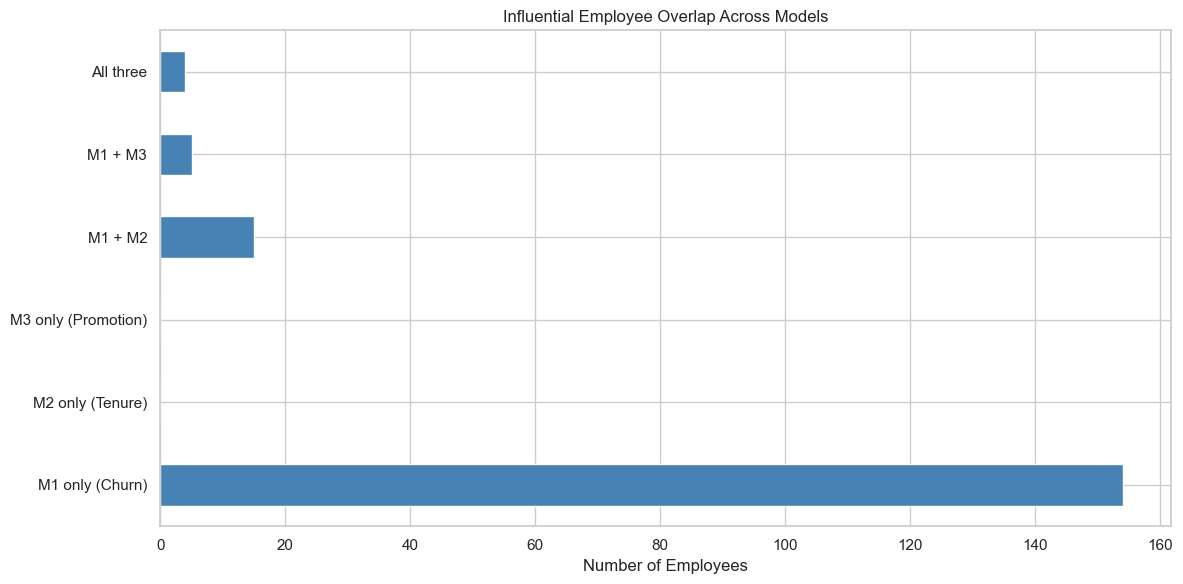

In [27]:
overlap_counts = {
    "M1 only (Churn)":         len(flagged_ids_m1 - flagged_ids_m2 - flagged_ids_m3),
    "M2 only (Tenure)":        len(flagged_ids_m2 - flagged_ids_m1 - flagged_ids_m3),
    "M3 only (Promotion)":     len(flagged_ids_m3 - flagged_ids_m1 - flagged_ids_m2),
    "M1 + M2":                 len(in_m1_and_m2 - flagged_ids_m3),
    "M1 + M3":                 len(in_m1_and_m3 - flagged_ids_m2),
    "All three":               len(in_all_three),
}

pd.Series(overlap_counts).plot(kind="barh", color="steelblue", edgecolor="white")
plt.title("Influential Employee Overlap Across Models")
plt.xlabel("Number of Employees")
plt.tight_layout()

# Section 6 - Analyzing Results from most viable model

Which model to use?

M1 (Logistic) is disqualified -  it was fitted on all 178 promoted employees and flagged all 178 as exceeding Cook's D > 4/n. 
-  That's not a useful filter, it's a consequence of the overfit model. The profiles it produces are not meaningfully distinguished from the general population.

M3 (MonthsToPromotion) is too narrow — it only covers the 178 promoted employees by definition. 
- Any profiles you extract are missing the 889 never-promoted employees entirely, which includes a large chunk of your high-performer churn story.

M2 is the right choice for three reasons:
- First, it ran on the 143 exited employees — which is exactly the population you care about for a churn analysis. These are people who actually left, so their profiles are directly relevant to the "at-risk segment" slide.
- Second, it produced clean, interpretable outliers — 19 flagged employees split into two meaningful groups: those who stayed much longer than their profile predicted (positive residuals, anomalously loyal) and those who left much earlier than predicted (negative residuals, anomalous early exits). Employee 5046 with a residual of −12 months is your headline case.
- Third, the model itself was statistically sound — R² = 0.22, significant F-statistic, reasonable sample size, and no quasi-separation warnings. The influence diagnostics are trustworthy.

In [29]:
df_exited["ResidualDirection"] = df_exited["resid_M2"].apply(
    lambda x: "Left earlier than expected" if x < 0 else "Stayed longer than expected"
)

flagged_m2_profiles = df_exited[df_exited["flagged_M2"]][[
    "EmployeeID", "ResidualDirection", "resid_M2"
]].merge(employee, on="EmployeeID", how="left")

flagged_m2_profiles = flagged_m2_profiles.merge(
    branch.rename(columns={"BranchNo": "Branch#"})[["Branch#", "BranchName", "Stars"]]
    .groupby(["Branch#", "BranchName"])["Stars"].mean().round(2).reset_index()
    .rename(columns={"Stars": "BranchAvgStars"}),
    on="Branch#", how="left"
)

flagged_m2_profiles["resid_M2"] = flagged_m2_profiles["resid_M2"].round(1)
flagged_m2_profiles = flagged_m2_profiles.sort_values("resid_M2")

print(flagged_m2_profiles[["EmployeeID", "ResidualDirection", "resid_M2",
                             "Role", "BranchName", "Wage", "AvgPerfScore",
                             "TenureMonths", "IsHighPerformer"]].to_string())

flagged_m2_profiles.to_csv("Outliers_Analysis/flagged_employee_profiles_M2.csv", index=False)

    EmployeeID            ResidualDirection  resid_M2        Role   BranchName         Wage  AvgPerfScore  TenureMonths  IsHighPerformer
13        5127   Left earlier than expected     -13.1      Server     Richmond      Premium         90.64      8.048620                1
12        5482   Left earlier than expected     -12.8      Server     Richmond      Premium         95.52      9.296978                1
14        5046   Left earlier than expected     -12.0      Server     Richmond      Premium         89.60      7.917214                1
6         5914   Left earlier than expected     -11.1      Server     Downtown  Competitive         80.24      7.161629                0
8         6012   Left earlier than expected      -8.9      Server  Main Street  Competitive         85.10      7.654402                0
2         5841   Left earlier than expected      -8.6      Server          UBC  Competitive         83.79      8.212878                0
1         5072   Left earlier than expect

In [30]:
# ── Visualization setup ──────────────────────────────────────────────────────
# Run this after the flagged_m2_profiles dataframe is built

early = flagged_m2_profiles[flagged_m2_profiles["ResidualDirection"] == "Left earlier than expected"].copy()
late  = flagged_m2_profiles[flagged_m2_profiles["ResidualDirection"] == "Stayed longer than expected"].copy()

colors = {
    "Left earlier than expected":   "#E24B4A",
    "Stayed longer than expected":  "#639922"
}

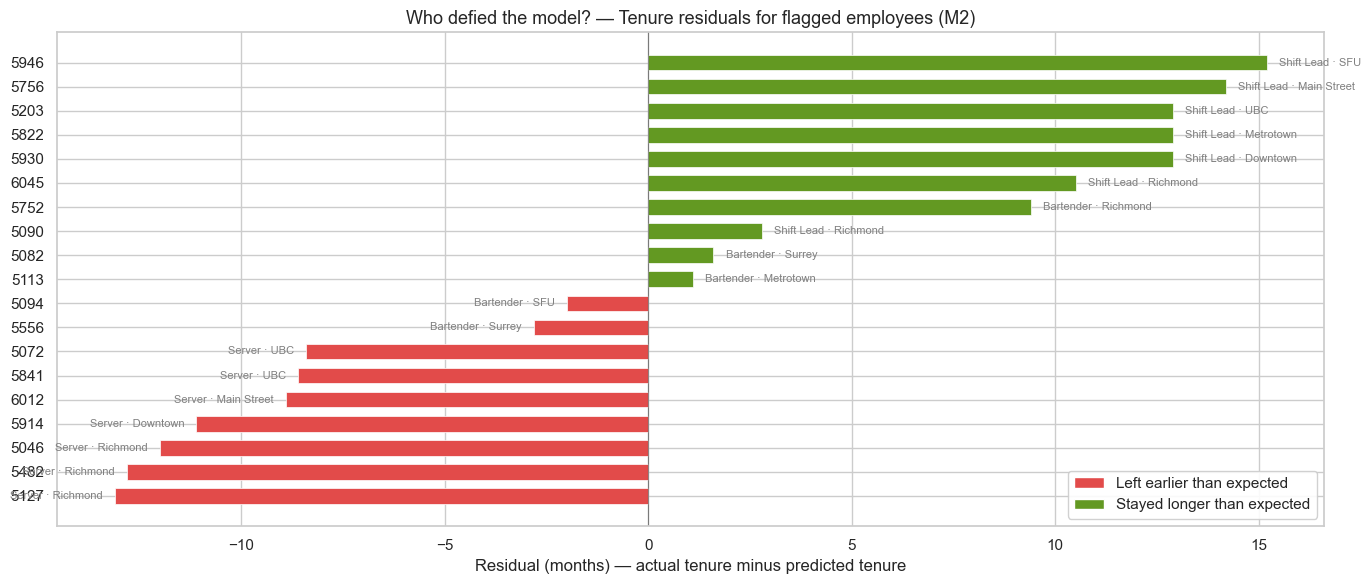

In [31]:
fig, ax = plt.subplots(figsize=(14, 6))

df_sorted = flagged_m2_profiles.sort_values("resid_M2")
bar_colors = df_sorted["ResidualDirection"].map(colors)

bars = ax.barh(
    df_sorted["EmployeeID"].astype(str),
    df_sorted["resid_M2"],
    color=bar_colors, edgecolor="white", linewidth=0.5, height=0.65
)

ax.axvline(0, color="black", linewidth=0.8, alpha=0.4)
ax.set_xlabel("Residual (months) — actual tenure minus predicted tenure")
ax.set_title("Who defied the model? — Tenure residuals for flagged employees (M2)", fontsize=13)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#E24B4A", label="Left earlier than expected"),
    Patch(facecolor="#639922", label="Stayed longer than expected"),
]
ax.legend(handles=legend_elements, loc="lower right", framealpha=0.9)

# Annotate role and branch on each bar
for _, row in df_sorted.iterrows():
    label = f"{row['Role']} · {row['BranchName']}"
    x_pos = row["resid_M2"] + (0.3 if row["resid_M2"] >= 0 else -0.3)
    ha = "left" if row["resid_M2"] >= 0 else "right"
    ax.text(x_pos, str(row["EmployeeID"]), label, va="center",
            ha=ha, fontsize=8, color="grey")

plt.tight_layout()
plt.savefig("m2_residual_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

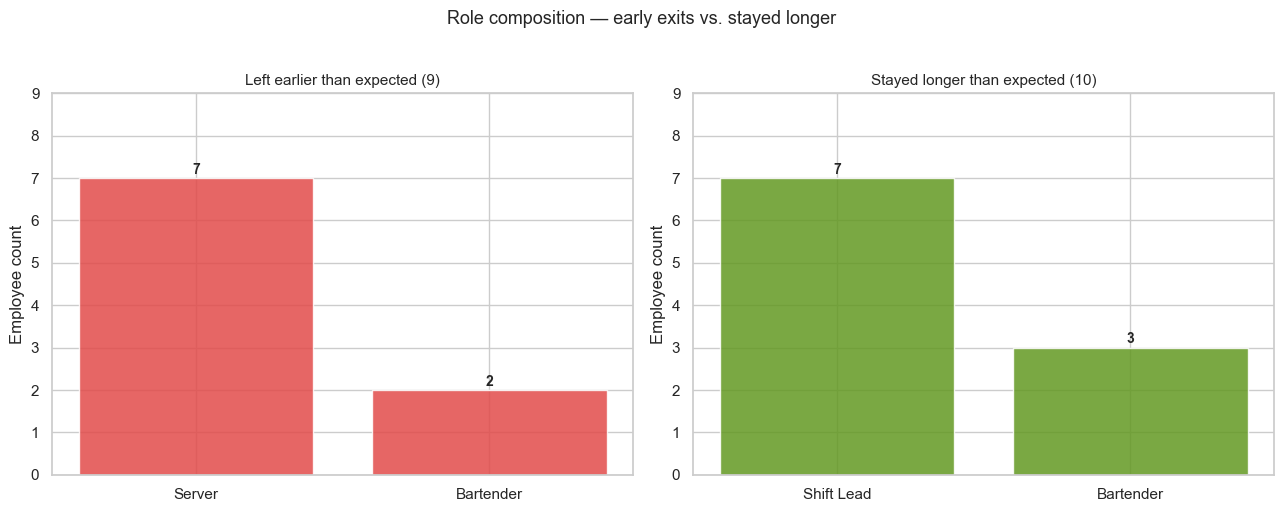

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (group_df, title, color) in zip(axes, [
    (early, "Left earlier than expected (9)", "#E24B4A"),
    (late,  "Stayed longer than expected (10)", "#639922"),
]):
    role_counts = group_df["Role"].value_counts()
    ax.bar(role_counts.index, role_counts.values,
           color=color, edgecolor="white", alpha=0.85)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Employee count")
    ax.set_ylim(0, 9)
    for i, v in enumerate(role_counts.values):
        ax.text(i, v + 0.1, str(v), ha="center", fontsize=10, fontweight="bold")

fig.suptitle("Role composition — early exits vs. stayed longer", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("m2_role_composition.png", dpi=150, bbox_inches="tight")
plt.show()

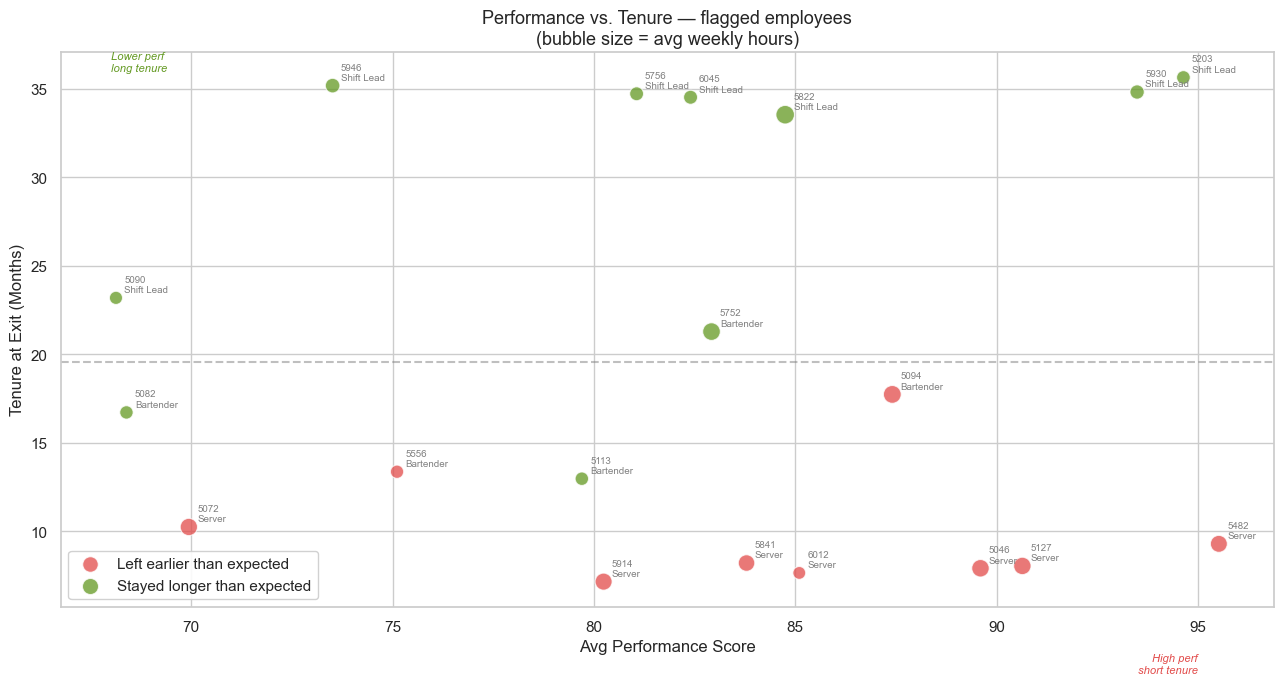

In [34]:
fig, ax = plt.subplots(figsize=(13, 7))

for direction, group in flagged_m2_profiles.groupby("ResidualDirection"):
    ax.scatter(
        group["AvgPerfScore"], group["TenureMonths"],
        c=colors[direction], label=direction,
        s=group["AvgWorkingHours/Week"] * 4,   # bubble size = hours worked
        alpha=0.75, edgecolors="white", linewidth=0.8
    )

# Annotate each point
for _, row in flagged_m2_profiles.iterrows():
    ax.annotate(
        f"{row['EmployeeID']}\n{row['Role']}",
        (row["AvgPerfScore"], row["TenureMonths"]),
        fontsize=7, xytext=(6, 4), textcoords="offset points",
        color="grey"
    )

ax.set_xlabel("Avg Performance Score")
ax.set_ylabel("Tenure at Exit (Months)")
ax.set_title("Performance vs. Tenure — flagged employees\n(bubble size = avg weekly hours)",
             fontsize=13)
ax.legend(framealpha=0.9)
ax.axhline(flagged_m2_profiles["TenureMonths"].mean(), color="grey",
           linestyle="--", alpha=0.5, label="Avg tenure")

# Quadrant labels
ax.text(95, 2, "High perf\nshort tenure", fontsize=8, color="#E24B4A",
        ha="right", style="italic")
ax.text(68, 36, "Lower perf\nlong tenure", fontsize=8, color="#639922",
        ha="left", style="italic")

plt.tight_layout()
plt.savefig("m2_perf_vs_tenure_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

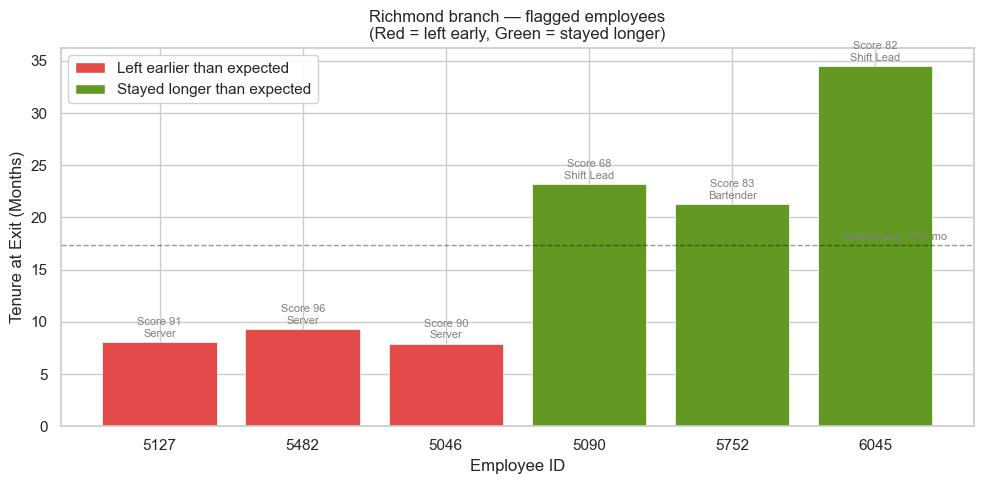

In [35]:
richmond = flagged_m2_profiles[flagged_m2_profiles["BranchName"] == "Richmond"].copy()
richmond = richmond.sort_values("resid_M2")

fig, ax = plt.subplots(figsize=(10, 5))

bar_colors_r = richmond["ResidualDirection"].map(colors)
bars = ax.bar(
    richmond["EmployeeID"].astype(str),
    richmond["TenureMonths"],
    color=bar_colors_r, edgecolor="white", linewidth=0.5
)

# Annotate score and role
for bar, (_, row) in zip(bars, richmond.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"Score {row['AvgPerfScore']:.0f}\n{row['Role']}",
        ha="center", fontsize=8, color="grey"
    )

ax.axhline(richmond["TenureMonths"].mean(), color="black",
           linestyle="--", alpha=0.4, linewidth=1)
ax.text(len(richmond) - 0.5,
        richmond["TenureMonths"].mean() + 0.5,
        f"Branch avg: {richmond['TenureMonths'].mean():.1f} mo",
        ha="right", fontsize=8, color="grey")

ax.set_xlabel("Employee ID")
ax.set_ylabel("Tenure at Exit (Months)")
ax.set_title("Richmond branch — flagged employees\n(Red = left early, Green = stayed longer)",
             fontsize=12)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="#E24B4A", label="Left earlier than expected"),
    Patch(facecolor="#639922", label="Stayed longer than expected"),
], framealpha=0.9)

plt.tight_layout()
plt.savefig("m2_richmond_deepdive.png", dpi=150, bbox_inches="tight")
plt.show()

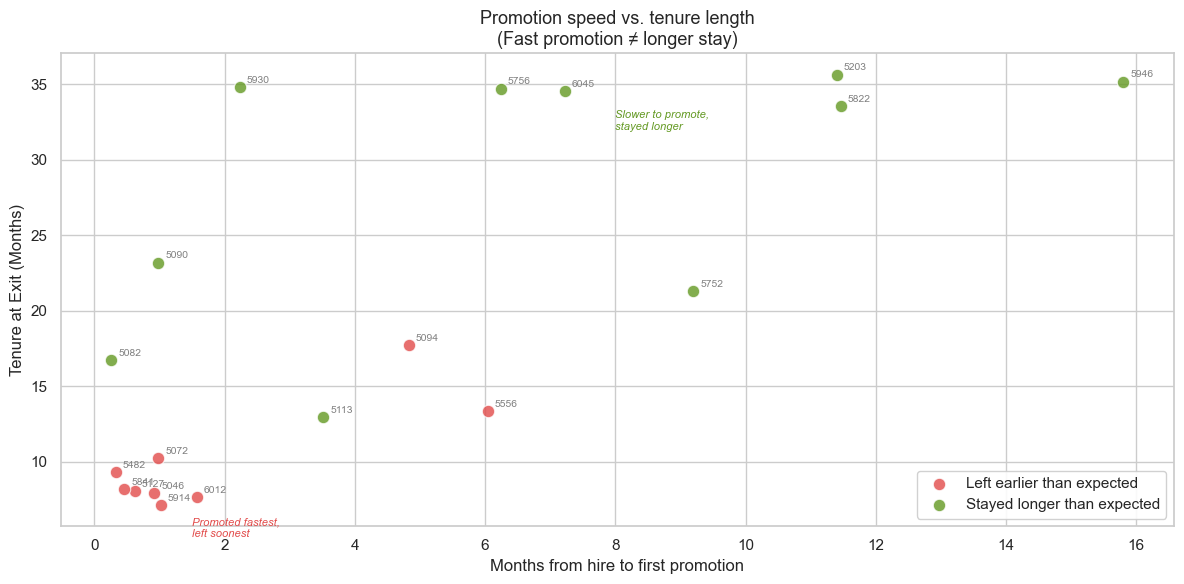

In [36]:
fig, ax = plt.subplots(figsize=(12, 6))

for direction, group in flagged_m2_profiles.groupby("ResidualDirection"):
    ax.scatter(
        group["MonthsToPromotion"], group["TenureMonths"],
        c=colors[direction], label=direction,
        s=80, alpha=0.8, edgecolors="white", linewidth=0.8
    )
    # Annotate
    for _, row in group.iterrows():
        ax.annotate(
            str(row["EmployeeID"]),
            (row["MonthsToPromotion"], row["TenureMonths"]),
            fontsize=7.5, xytext=(5, 3), textcoords="offset points", color="grey"
        )

ax.set_xlabel("Months from hire to first promotion")
ax.set_ylabel("Tenure at Exit (Months)")
ax.set_title("Promotion speed vs. tenure length\n(Fast promotion ≠ longer stay)",
             fontsize=13)
ax.legend(framealpha=0.9)

# Trend annotation
ax.text(1.5, 5, "Promoted fastest,\nleft soonest",
        fontsize=8, color="#E24B4A", style="italic")
ax.text(8, 32, "Slower to promote,\nstayed longer",
        fontsize=8, color="#639922", style="italic")

plt.tight_layout()
plt.savefig("m2_promo_speed_vs_tenure.png", dpi=150, bbox_inches="tight")
plt.show()

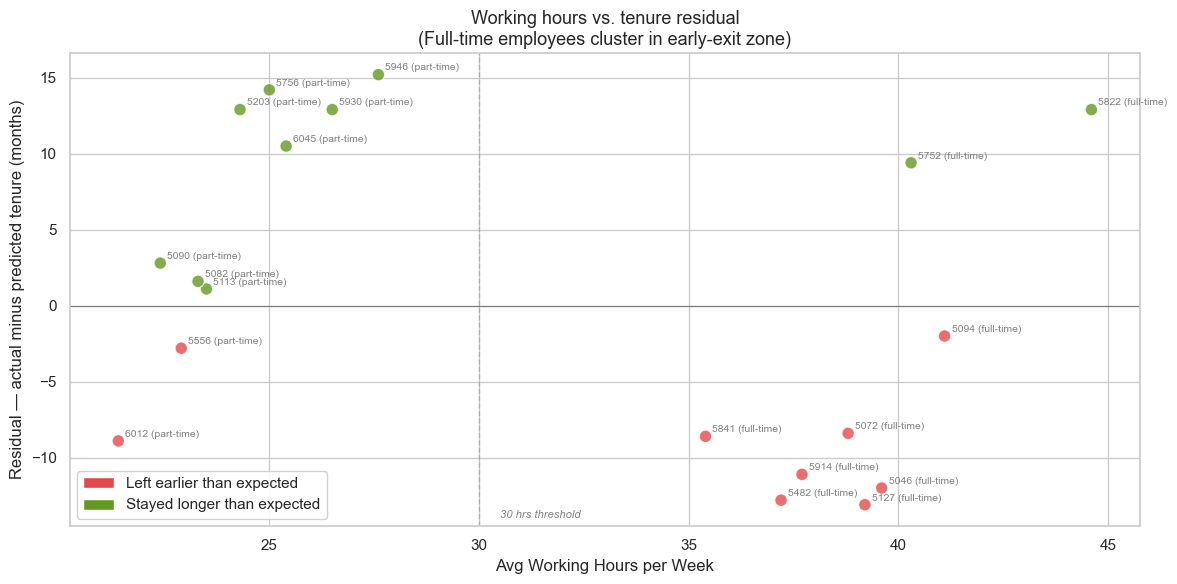

In [37]:
fig, ax = plt.subplots(figsize=(12, 6))

bar_colors_h = flagged_m2_profiles.sort_values("resid_M2")["ResidualDirection"].map(colors)
df_h = flagged_m2_profiles.sort_values("resid_M2")

ax.scatter(
    df_h["AvgWorkingHours/Week"], df_h["resid_M2"],
    c=bar_colors_h, s=80, alpha=0.8, edgecolors="white", linewidth=0.8
)

for _, row in df_h.iterrows():
    ax.annotate(
        f"{row['EmployeeID']} ({row['Position']})",
        (row["AvgWorkingHours/Week"], row["resid_M2"]),
        fontsize=7.5, xytext=(5, 3), textcoords="offset points", color="grey"
    )

ax.axhline(0, color="black", linewidth=0.8, alpha=0.4)
ax.axvline(30, color="grey", linestyle="--", alpha=0.4, linewidth=1)
ax.text(30.5, -14, "30 hrs threshold", fontsize=8, color="grey", style="italic")

ax.set_xlabel("Avg Working Hours per Week")
ax.set_ylabel("Residual — actual minus predicted tenure (months)")
ax.set_title("Working hours vs. tenure residual\n(Full-time employees cluster in early-exit zone)",
             fontsize=13)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="#E24B4A", label="Left earlier than expected"),
    Patch(facecolor="#639922", label="Stayed longer than expected"),
], framealpha=0.9)

plt.tight_layout()
plt.savefig("m2_hours_vs_residual.png", dpi=150, bbox_inches="tight")
plt.show()